In [69]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

customer_data = pd.read_csv(r"D:\data_mining\tuan7\data.csv")
customer_data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [80]:
selected_data = customer_data.iloc[:, 3:5]
selected_data

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [73]:
def Euclidean(X, Y, method):
    Dist = []
    for i in range(0, len(X), 2):
        for j in range(0, len(Y), 2):
            distance = (X[i] - Y[j]) ** 2 + (X[i + 1] - Y[j + 1]) ** 2
            Dist.append(np.sqrt(distance))
    if method == "single":
        return np.min(Dist)
    if method == "complete":
        return np.max(Dist)
    return np.average(Dist)


def hierarchic(data, n_cluster, method):
    Points = []
    for i in range(data.shape[0]):
        Points.append([int(data.iloc[i, 0]), int(data.iloc[i, 1])])

    n = len(Points)

    while(n > n_cluster):
        Min = float('inf')
        for i in range(len(Points)):
            for j in range(i + 1, len(Points)):
                dist = Euclidean(Points[i], Points[j], method=method)
                if dist < Min:
                    Min = dist
                    indx, indy = i, j

        for k in range(0, len(Points[indy])):
            Points[indx].append(Points[indy][k])
        Points.pop(indy)

        n -= 1

    return Points

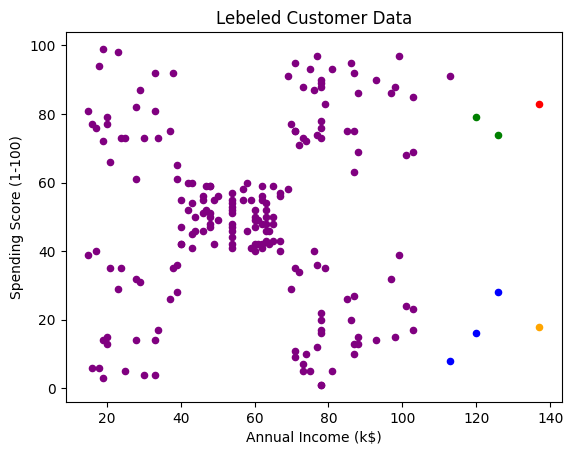

In [81]:
Points = hierarchic(selected_data, 5, method="single")
colors = ['purple', 'blue', 'green', 'orange', 'red']

for i in range(len(Points)):
    current_cluster = Points[i]
    x = [current_cluster[j] for j in range(0, len(current_cluster), 2)]
    y = [current_cluster[j] for j in range(1, len(current_cluster), 2)]

    plt.scatter(x, y, s=20, c=colors[i], label=f'Cluster {i+1} ({len(x)} điểm)')

plt.title('Lebeled Customer Data')

plt.xlabel('Annual Income (k$)') 
plt.ylabel('Spending Score (1-100)')
plt.show()

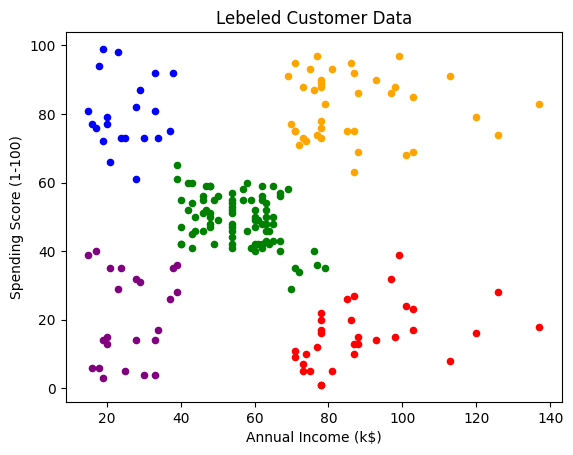

In [82]:
Points = hierarchic(selected_data, 5, method="complete")
colors = ['purple', 'blue', 'green', 'orange', 'red']

for i in range(len(Points)):
    current_cluster = Points[i]
    x = [current_cluster[j] for j in range(0, len(current_cluster), 2)]
    y = [current_cluster[j] for j in range(1, len(current_cluster), 2)]

    plt.scatter(x, y, s=20, c=colors[i], label=f'Cluster {i+1} ({len(x)} điểm)')

plt.title('Lebeled Customer Data')

plt.xlabel('Annual Income (k$)') 
plt.ylabel('Spending Score (1-100)')
plt.show()

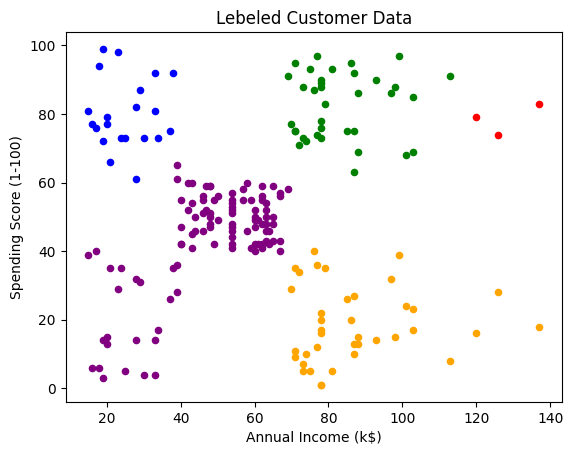

In [83]:
Points = hierarchic(selected_data, 5, method="average")
colors = ['purple', 'blue', 'green', 'orange', 'red']

for i in range(len(Points)):
    current_cluster = Points[i]
    x = [current_cluster[j] for j in range(0, len(current_cluster), 2)]
    y = [current_cluster[j] for j in range(1, len(current_cluster), 2)]

    plt.scatter(x, y, s=20, c=colors[i], label=f'Cluster {i+1} ({len(x)} điểm)')

plt.title('Lebeled Customer Data')

plt.xlabel('Annual Income (k$)') 
plt.ylabel('Spending Score (1-100)')
plt.show()